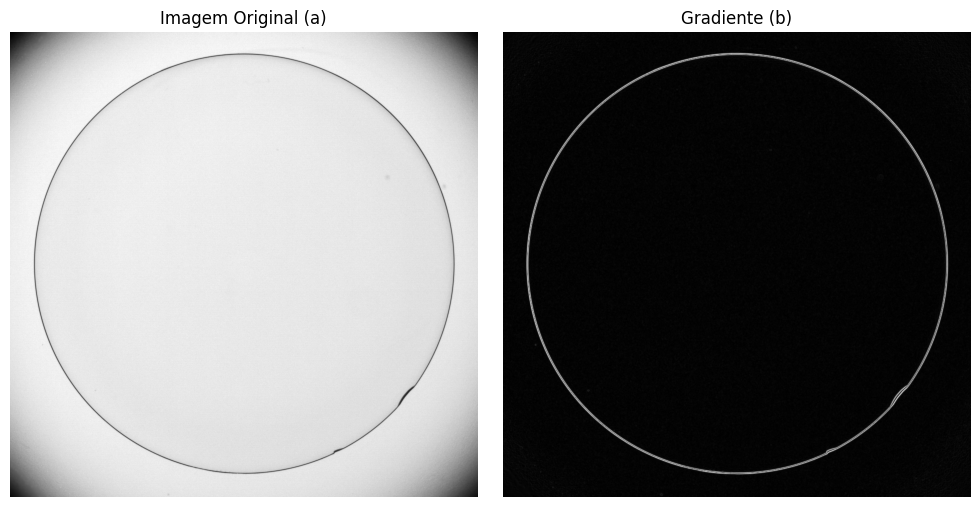

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io, color, filters, util

# 1. Carregar a imagem da Figura 3.42
# Certifique-se de que a imagem 'image_eede87.png' esteja no mesmo diretório
# do seu notebook, ou altere o caminho de acordo.
image_path = './images/FIG034_2.TIF'

try:
    fig_3_42 = io.imread(image_path)
    if fig_3_42 is None:
        raise FileNotFoundError("Erro: Imagem da Figura 3.42 não encontrada.")
except FileNotFoundError as e:
    print(e)
    exit()

img_original = fig_3_42

if img_original.ndim > 2:
    grayscale_img = color.rgb2gray(img_original)
else:
    grayscale_img = util.img_as_float(img_original)


grad_x = filters.sobel_h(grayscale_img)
grad_y = filters.sobel_v(grayscale_img)

# Magnitude do gradiente
magnitude_gradiente = np.sqrt(grad_x**2 + grad_y**2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# a) Imagem Original (recortada)
axes[0].imshow(grayscale_img, cmap='gray')
axes[0].set_title('Imagem Original (a)')
axes[0].axis('off')

# b) Magnitude do Gradiente (Sobel)
axes[1].imshow(magnitude_gradiente, cmap='gray')
axes[1].set_title('Gradiente (b)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

io.imsave('T10-gradiente.png', util.img_as_ubyte(magnitude_gradiente))